In [1]:
import pandas as pd
import numpy as np
import re
import zipfile

zip_path = "original_kaggle_data_download_archive.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())  # See what files are inside
    f1 = pd.read_csv(z.open("1429_1.csv"))
    f2 = pd.read_csv(z.open("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
    f3 = pd.read_csv(z.open("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

['1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']


/tmp/ipykernel_21045/2382996036.py:10: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  f1 = pd.read_csv(z.open("1429_1.csv"))


In [2]:
"""
Data preparation for the Automated Customer Reviews project.
Merges the 3 raw Datafiniti/Amazon review exports, deduplicates, cleans the
corrupted `name` field, maps star ratings to sentiment classes, and writes
a single clean dataset for downstream modeling.
"""

OUT_PATH = "clean_reviews.csv"

print(f"f1 {f1.shape}, f2 {f2.shape}, f3 {f3.shape}")

# ---- Keep only columns relevant to NLP tasks ----
keep_cols = ["id", "name", "asins", "brand", "categories", "primaryCategories",
             "reviews.date", "reviews.rating", "reviews.text", "reviews.title"]

for df in (f1, f2, f3):
    for c in keep_cols:
        if c not in df.columns:
            df[c] = np.nan

merged = pd.concat([f1[keep_cols], f2[keep_cols], f3[keep_cols]], ignore_index=True)
print(f"merged raw {merged.shape}")

# ---- Deduplicate: same product + review text + rating ----
merged = merged.dropna(subset=["reviews.text", "reviews.rating"])
merged = merged.drop_duplicates(subset=["id", "reviews.text", "reviews.rating"])
print(f"after dedup {merged.shape}")
print(f"unique product IDs: {merged['id'].nunique()}")
print(f"unique product names (raw): {merged['name'].nunique()}")

# ---- Fix corrupted `name` field (two names concatenated together) ----
def clean_name(name):
    if pd.isna(name):
        return name
    name = str(name)
    # Datafiniti corruption pattern: "Name A,,,,Name B" or names glued with commas
    # Keep first product-name segment (before a run of 2+ commas, or before an
    # obvious second product name starting after a comma cluster)
    parts = re.split(r",{2,}", name)
    first = parts[0].strip()
    return first

merged["name_clean"] = merged["name"].apply(clean_name)
print(f"unique product names (cleaned): {merged['name_clean'].nunique()}")



f1 (34660, 21), f2 (5000, 24), f3 (28332, 24)
merged raw (67992, 10)
after dedup (59743, 10)
unique product IDs: 89
unique product names (raw): 119
unique product names (cleaned): 109


In [3]:
# ---- Sentiment mapping ----
def map_sentiment(rating):
    if pd.isna(rating):
        return np.nan
    rating = int(rating)
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

merged["sentiment"] = merged["reviews.rating"].apply(map_sentiment)
merged = merged.dropna(subset=["sentiment"])

# ---- Combine title + text as model input ----
merged["review_text_full"] = (
    merged["reviews.title"].fillna("") + ". " + merged["reviews.text"].fillna("")
).str.strip()
merged = merged[merged["review_text_full"].str.len() > 3]

print("\nFinal dataset:")
print(f"  rows: {len(merged)}")
print(f"  unique product IDs: {merged['id'].nunique()}")
print(f"  unique cleaned product names: {merged['name_clean'].nunique()}")
print("\nSentiment class distribution:")
print(merged["sentiment"].value_counts())
print(merged["sentiment"].value_counts(normalize=True).round(3))

merged.to_csv(OUT_PATH, index=False)
print(f"\nSaved -> {OUT_PATH}")


Final dataset:
  rows: 59743
  unique product IDs: 89
  unique cleaned product names: 109

Sentiment class distribution:
sentiment
positive    54841
neutral      2588
negative     2314
Name: count, dtype: int64
sentiment
positive    0.918
neutral     0.043
negative    0.039
Name: proportion, dtype: float64

Saved -> clean_reviews.csv



<hr>

## Create a unique product table

In [4]:
# ---- Clustering only the unique product names ----

unique_products = merged["name_clean"].drop_duplicates()

print(len(unique_products))

110


## Convert to TF-IDF vectors

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2)
)
unique_products = pd.Series(unique_products).dropna().astype(str)
X = vectorizer.fit_transform(unique_products)

## Determine the optimal number of clusters

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


K = range(2, 11)

inertia = []
silhouette = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    # Elbow Method
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    silhouette.append(
        silhouette_score(X, labels)
    )

## Elbow Method

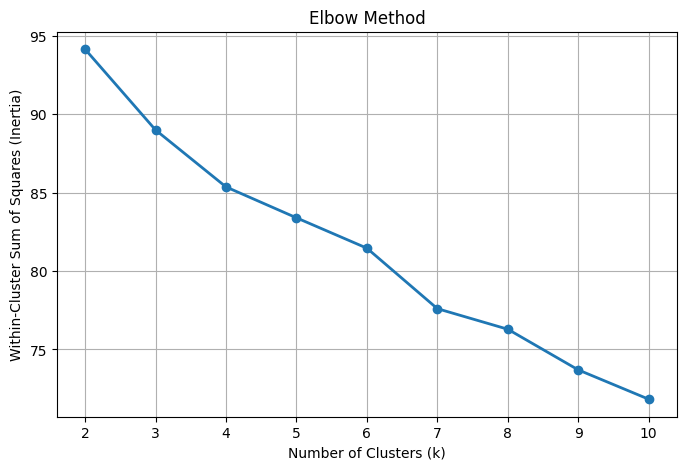

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.grid(True)

plt.show()  # ---- Look for the point where the curve starts to flatten ("the elbow").

## Silhouette Score

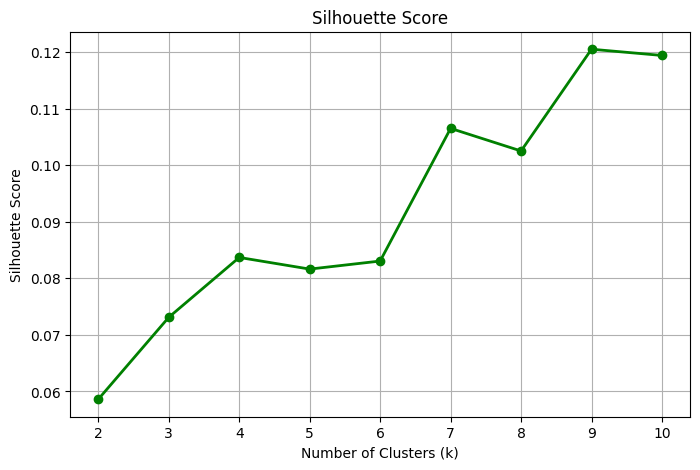

In [8]:
# --- The highest Silhouette Score generally indicates the best separation between clusters.

plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette,
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

# Table Results

In [9]:
import pandas as pd

results = pd.DataFrame({
    "Clusters": list(K),
    "Inertia": inertia,
    "Silhouette Score": silhouette
})

display(results)

,Clusters,Inertia,Silhouette Score
0,2,94.147330,0.058628
1,3,88.998625,0.073120
2,4,85.367373,0.083700
3,5,83.397259,0.081640
4,6,81.460168,0.083065
5,7,77.603479,0.106523
6,8,76.291114,0.102529
7,9,73.698947,0.120524
8,10,71.828884,0.119423


## Automatically select the best k

In [10]:
best_k = K[np.argmax(silhouette)]

print(f"Best number of clusters according to Silhouette Score: {best_k}")

Best number of clusters according to Silhouette Score: 9


## Run KMeans

In [11]:
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X)

products = pd.DataFrame({
    "product": unique_products,
    "cluster": labels
})

## Interpret each cluster

In [12]:
for c in sorted(products.cluster.unique()):

    print("="*60)

    print(f"Cluster {c}")

    display(
        products.loc[
            products.cluster==c
        ].sort_values("product")
    )

Cluster 0


,product,cluster
59051,All-New Kindle Oasis E-reader - 7 High-Resolut...,0
65531,All-New Kindle Oasis E-reader - 7 High-Resolut...,0
62365,All-New Kindle Oasis E-reader - 7 High-Resolut...,0
14446,Kindle Oasis E-reader with Leather Charging Co...,0
39422,Kindle Oasis E-reader with Leather Charging Co...,0
2814,Kindle Oasis E-reader with Leather Charging Co...,0
62359,Kindle Oasis E-reader with Leather Charging Co...,0
20987,"Kindle Paperwhite E-reader - White, 6 High-Res...",0
52544,"Kindle Voyage E-reader, 6 High-Resolution Disp...",0
20390,"Kindle Voyage E-reader, 6 High-Resolution Disp...",0


Cluster 1


,product,cluster
25033,Amazon - Amazon Tap Portable Bluetooth and Wi-...,1
21164,"Amazon - Fire 16GB (5th Gen, 2015 Release) - B...",1
24891,Amazon Fire Hd 6 Standing Protective Case(4th ...,1
21025,Amazon Fire Hd 8 8in Tablet 16gb Black B018szt...,1
65523,Amazon Fire TV Gaming Edition Streaming Media ...,1
35601,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,1
25352,Amazon Fire Tv,1
2881,Amazon Kindle Lighted Leather Cover,1
17214,Amazon Kindle Paperwhite - eBook reader - 4 GB...,1
15526,Amazon Kindle Touch Leather Case (4th Generati...,1


Cluster 2


...

,product,cluster
57438,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",4
59062,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",4
59079,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",4
58920,"Amazon Fire HD 8 with Alexa (8"" HD Display Tab...",4
65549,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",4
14478,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",4
63868,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",4
3051,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",4
39369,"Fire HD 8 Tablet with Alexa, 8"" HD Display, 32...",4
61457,"Fire Tablet with Alexa, 7 Display, 16 GB, Blue...",4


Cluster 5


,product,cluster
53046,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
36279,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
53157,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
36293,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
2905,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
38290,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",5
39461,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",5
3266,"All-New Kindle E-reader - Black, 6 Glare-Free ...",5
52495,"All-New Kindle E-reader - Black, 6"" Glare-Free...",5


Cluster 6


,product,cluster
53040,All-new Echo (2nd Generation) with improved so...,6
35605,Amazon - Echo Plus w/ Built-In Hub - Silver,6
51881,Amazon Echo (1st Generationcertified) Color:Wh...,6
52528,Amazon Echo (2nd Generation) Smart Assistant O...,6
48009,Amazon Echo Show - Black,6
34756,Amazon Echo Show Alexa-enabled Bluetooth Speak...,6
21017,Amazon Echo and Fire TV Power Adapter,6
48007,Amazon Echo ‚Äì White,6
53037,Certified Refurbished Amazon Echo,6
24851,Echo (Black),6


<hr>

## Product Category Clustering

In [13]:
# ============================================================
# STEP 1: Create a dictionary to map cluster IDs to names
# ============================================================

cluster_names = {
    0: "E-Readers",
    1: "Others",
    2: "Tablets for Kids",
    3: "Chargers & Adapters",
    4: "Tablets with Alexa",
    5: "Tablets",
    6: "Smart Assistants"
}

# ============================================================
# STEP 2: Add descriptive names to the products lookup table
# ============================================================
"""
products["cluster_name"] = products["cluster"].map(cluster_names)

# Check the result
display(products.head())
"""
# ============================================================
# STEP 3: Merge the cluster information back into the full dataset
# ============================================================

products = pd.DataFrame({
    "name_clean": unique_products,
    "cluster": labels
})

products["cluster_name"] = products["cluster"].map(cluster_names)

merged = merged.merge(
    products[["name_clean", "cluster", "cluster_name"]],
    on="name_clean",
    how="left"
)

""""
merged = merged.merge(
    products[
        [
            "name_clean",
            "cluster",
            "cluster_name"
        ]
    ],
    on="name_clean",
    how="left"
)
"""
# ============================================================
# STEP 4: Verify the merge
# ============================================================

print("Merged dataset shape:", merged.shape)

display(
    merged[
        [
            "name_clean",
            "cluster",
            "cluster_name"
        ]
    ].head(15)
)

# ============================================================
# STEP 5: Number of products per cluster
# ============================================================

cluster_summary = (
    merged
    .groupby(["cluster", "cluster_name"])
    .size()
    .reset_index(name="Number of Products")
    .sort_values("cluster")
)

display(cluster_summary)

# ============================================================
# STEP 6: Display sample products from each cluster
# ============================================================

for cluster_id in sorted(cluster_names.keys()):

    print("=" * 70)
    print(f"Cluster {cluster_id}: {cluster_names[cluster_id]}")
    print("=" * 70)

    display(
        merged.loc[
            merged["cluster"] == cluster_id,
            "name_clean"
        ]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

Merged dataset shape: (59743, 15)


,name_clean,cluster,cluster_name
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
6,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
7,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
8,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
9,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets


,cluster,cluster_name,Number of Products
0,0.0,E-Readers,849
1,1.0,Others,18360
2,2.0,Tablets for Kids,5366
3,3.0,Chargers & Adapters,354
4,4.0,Tablets with Alexa,4628
5,5.0,Tablets,18641
6,6.0,Smart Assistants,4786


Cluster 0: E-Readers


,name_clean
0,All-New Kindle Oasis E-reader - 7 High-Resolut...
1,All-New Kindle Oasis E-reader - 7 High-Resolut...
2,All-New Kindle Oasis E-reader - 7 High-Resolut...
3,Kindle Oasis E-reader with Leather Charging Co...
4,Kindle Oasis E-reader with Leather Charging Co...
5,Kindle Oasis E-reader with Leather Charging Co...
6,Kindle Oasis E-reader with Leather Charging Co...
7,"Kindle Paperwhite E-reader - White, 6 High-Res..."
8,"Kindle Voyage E-reader, 6 High-Resolution Disp..."
9,"Kindle Voyage E-reader, 6 High-Resolution Disp..."


...

,name_clean
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ..."
1,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp..."
2,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp..."
3,"Amazon Fire HD 8 with Alexa (8"" HD Display Tab..."
4,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ..."
5,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ..."
6,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ..."
7,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ..."
8,"Fire HD 8 Tablet with Alexa, 8"" HD Display, 32..."
9,"Fire Tablet with Alexa, 7 Display, 16 GB, Blue..."


Cluster 5: Tablets


,name_clean
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
6,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi..."
7,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi..."
8,"All-New Kindle E-reader - Black, 6 Glare-Free ..."
9,"All-New Kindle E-reader - Black, 6"" Glare-Free..."


Cluster 6: Smart Assistants


,name_clean
0,All-new Echo (2nd Generation) with improved so...
1,Amazon - Echo Plus w/ Built-In Hub - Silver
2,Amazon Echo (1st Generationcertified) Color:Wh...
3,Amazon Echo (2nd Generation) Smart Assistant O...
4,Amazon Echo Show - Black
5,Amazon Echo Show Alexa-enabled Bluetooth Speak...
6,Amazon Echo and Fire TV Power Adapter
7,Amazon Echo ‚Äì White
8,Certified Refurbished Amazon Echo
9,Echo (Black)


## 3. Generate a summary for each product category using Generative AI

For each product category from the clustering step, we generate a short blog-post-style
article covering:
- **Top 3 products** in the category and what sets them apart
- **Top complaints** for each of those products
- The **worst product** in the category and why it should be avoided

Per the assignment guidance, we start with a **pretrained generative model** (DistilBART,
a distilled BART checkpoint from Hugging Face) to abstractively summarize review text,
rather than going straight to a hosted LLM API.

In [14]:
pip install --upgrade transformers

After upgrading the `transformers` library, you'll need to restart the runtime for the changes to take effect. You can do this by navigating to 'Runtime' -> 'Restart runtime' in the Colab menu.

In [15]:
# ============================================================
# STEP 1: Per-product stats within each category
# ============================================================

MIN_REVIEWS = 9  # minimum reviews for a product to be considered statistically meaningful

product_stats = (
    merged
    .groupby(["cluster", "cluster_name", "name_clean"])
    .agg(
        review_count=("reviews.rating", "size"),
        avg_rating=("reviews.rating", "mean"),
        negative_count=("sentiment", lambda s: (s == "negative").sum()),
    )
    .reset_index()
)
product_stats["negative_rate"] = product_stats["negative_count"] / product_stats["review_count"]

print(f"Products with >= {MIN_REVIEWS} reviews: "
      f"{(product_stats['review_count'] >= MIN_REVIEWS).sum()} / {len(product_stats)}")

product_stats.sort_values(["cluster", "review_count"], ascending=[True, False]).head(10)

Products with >= 9 reviews: 57 / 109


,cluster,cluster_name,name_clean,review_count,avg_rating,negative_count,negative_rate
9,0.0,E-Readers,"Kindle Voyage E-reader, 6 High-Resolution Disp...",580,4.743103,4,0.006897
5,0.0,E-Readers,Kindle Oasis E-reader with Leather Charging Co...,68,4.617647,2,0.029412
6,0.0,E-Readers,Kindle Oasis E-reader with Leather Charging Co...,62,4.612903,2,0.032258
3,0.0,E-Readers,Kindle Oasis E-reader with Leather Charging Co...,36,4.388889,2,0.055556
7,0.0,E-Readers,"Kindle Paperwhite E-reader - White, 6 High-Res...",30,4.533333,1,0.033333
4,0.0,E-Readers,Kindle Oasis E-reader with Leather Charging Co...,27,4.777778,1,0.037037
2,0.0,E-Readers,All-New Kindle Oasis E-reader - 7 High-Resolut...,22,4.590909,1,0.045455
8,0.0,E-Readers,"Kindle Voyage E-reader, 6 High-Resolution Disp...",13,4.923077,0,0.000000
1,0.0,E-Readers,All-New Kindle Oasis E-reader - 7 High-Resolut...,7,4.428571,0,0.000000
0,0.0,E-Readers,All-New Kindle Oasis E-reader - 7 High-Resolut...,4,4.750000,0,0.000000


In [16]:
# ============================================================
# STEP 2: Pick the top 3 and worst product per category
# ============================================================

def get_category_products(cluster_id, min_reviews=MIN_REVIEWS, top_n=3):
    """Return (top_products_df, worst_product_row) for a given cluster."""
    cat = product_stats[
        (product_stats["cluster"] == cluster_id) &
        (product_stats["review_count"] >= min_reviews)
    ].copy()

    if cat.empty:
        # Fall back to all products in the category if none pass the review threshold
        cat = product_stats[product_stats["cluster"] == cluster_id].copy()

    # Blend popularity (review_count) and quality (avg_rating) to rank top products
    cat["rank_score"] = cat["avg_rating"] * np.log1p(cat["review_count"])
    top_products = cat.sort_values("rank_score", ascending=False).head(top_n)

    # Worst product = lowest average rating among products with enough reviews
    worst_product = cat.sort_values("avg_rating", ascending=True).iloc[0] if not cat.empty else None

    return top_products, worst_product

In [17]:
# ============================================================
# STEP 3: Load a pretrained generative model (Llama Instruct)
# ============================================================

import torch
from transformers import pipeline

# meta-llama/Llama-3.2-3B-Instruct is gated on Hugging Face: request access
# on the model page, then run `huggingface-cli login` (or set HF_TOKEN) once.
LLAMA_MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"

llama = pipeline(
    "text-generation",
    model=LLAMA_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

def product_review_text(name_clean, sentiment=None, max_reviews=40):
    """Concatenate review text for a product, optionally filtered by sentiment."""
    subset = merged[merged["name_clean"] == name_clean]
    if sentiment:
        subset = subset[subset["sentiment"] == sentiment]
    texts = subset["review_text_full"].dropna().head(max_reviews).tolist()
    return " ".join(texts)

def summarize_text(text, instruction="Summarize the recurring themes in these customer reviews in 1-2 concise sentences.",
                    max_new_tokens=60, max_length=40, min_length=10):
    """Use Llama Instruct to turn a blob of review text into a short summary."""
    text = text.strip()
    if not text:
        return "Not enough review text available."
    text = text[:4000]
    if len(text.split()) < 20:
        return summarizer(text, max_length=max_length, min_length=min_length)[0]["summary_text"]

    messages = [
        {"role": "system", "content": "You are a concise product-review analyst. "
                                       "Respond with only the summary, no preamble."},
        {"role": "user", "content": f"{instruction}\n\nReviews:\n{text}"},
    ]
    try:
        out = llama(
            messages,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llama.tokenizer.eos_token_id,
        )
        reply = out[0]["generated_text"][-1]["content"]
        return reply.strip()
    except Exception as e:
        return f"(summary unavailable: {e})"

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

In [18]:
# ============================================================
# STEP 4: Assemble the category article
# ============================================================

def generate_category_article(cluster_id):
    cluster_name = cluster_names[cluster_id]
    top_products, worst_product = get_category_products(cluster_id)
    cat_all = product_stats[product_stats["cluster"] == cluster_id]

    lines = [f"# {cluster_name}: What the Reviews Really Say\n"]
    lines.append(
        f"We analyzed {int(cat_all['review_count'].sum()):,} customer reviews across "
        f"{len(cat_all)} products in the **{cluster_name}** category.\n"
    )

    lines.append("## Top 3 Products\n")
    for _, row in top_products.iterrows():
        diff_summary = summarize_text(product_review_text(row["name_clean"], sentiment="positive"))
        complaint_summary = summarize_text(
            product_review_text(row["name_clean"], sentiment="negative"),
            max_length=40, min_length=10,
        )
        lines.append(f"### {row['name_clean']}")
        lines.append(f"*{row['review_count']} reviews, {row['avg_rating']:.1f}/5 average rating*\n")
        lines.append(f"**What sets it apart:** {diff_summary}\n")
        lines.append(f"**Top complaints:** {complaint_summary}\n")

    lines.append("## Worst Product in the Category\n")
    if worst_product is not None:
        worst_summary = summarize_text(
            product_review_text(worst_product["name_clean"], sentiment="negative"),
            max_length=50, min_length=15,
        )
        lines.append(
            f"**{worst_product['name_clean']}** ({worst_product['review_count']} reviews, "
            f"{worst_product['avg_rating']:.1f}/5 average rating) is the weakest performer "
            f"in this category.\n"
        )
        lines.append(f"**Why to avoid it:** {worst_summary}\n")

    return "\n".join(lines)

In [19]:
# ============================================================
# STEP 5: Generate an article for every category
# ============================================================
# Note: the "Others" cluster is a mixed-bag catch-all from the earlier
# clustering step (unrelated accessories/non-electronics), so its summary
# is less coherent than the well-defined categories - kept for completeness.

category_articles = {}
for cid in sorted(cluster_names.keys()):
    print(f"Generating summary for cluster {cid}: {cluster_names[cid]}...")
    category_articles[cid] = generate_category_article(cid)

print("\nDone generating all category articles.")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Generating summary for cluster 0: E-Readers...


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_len

Generating summary for cluster 1: Others...


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set.

...

Generating summary for cluster 5: Tablets...


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Generating summary for cluster 6: Smart Assistants...


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs


Done generating all category articles.


In [20]:
# Preview one category article
print(category_articles[5])  # Tablets

# Tablets: What the Reviews Really Say

We analyzed 18,641 customer reviews across 16 products in the **Tablets** category.

## Top 3 Products

### Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta
*10962 reviews, 4.5/5 average rating*

**What sets it apart:** Most reviewers praise the product's ease of use, great reading experience, and value for money, with some noting its lightweight and long-lasting battery life. A few reviewers mention limitations, such as the screen resolution and the need for decent light to read comfortably.

**Top complaints:** Most customers express dissatisfaction with the device's performance, display quality, and compatibility with non-Amazon apps, with many citing issues with screen brightness, navigation, and connectivity. Some reviewers mention that the device is slow, has poor battery life, and is prone to crashes and malfunctions.

### All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
*2814 re

In [21]:
# ============================================================
# STEP 6: Save all category articles to a single markdown file
# ============================================================

OUT_SUMMARY_PATH = "category_summaries.md"

with open(OUT_SUMMARY_PATH, "w", encoding="utf-8") as f:
    for cid in sorted(category_articles.keys()):
        f.write(category_articles[cid])
        f.write("\n\n---\n\n")

print(f"Saved -> {OUT_SUMMARY_PATH}")

Saved -> category_summaries.md
